## EDA: heatmap, boxplot, and distributions

This notebook is a **guided tour** of common exploratory plots. For each section you get: (1) what the chart type is for, (2) how to read the graphic, and (3) what the **example figures** below are trying to show.

### Chart types covered

- **Heatmap** -- turns a table of numbers into a color grid. Here we use it for **pairwise correlations**: how strongly two numeric features move together.
- **Boxplot** -- summarizes one numeric variable in each category (median, spread, outliers). Good for comparing groups (e.g. age by ticket class).
- **Histogram + KDE** -- shows how often values fall in ranges (histogram) and a **smooth estimate** of the underlying density (KDE).
- **Q-Q plot** -- checks whether data look **roughly normal** (points near a straight line).
- **Violin plot** -- like a boxplot plus a **density shape** on the sides so you see where values pile up.

### Data

CSV files are loaded from the repository **Dataset/** folder: houseprice.csv (Ames housing) and 	itanic.csv (passengers).



In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")

# Notebook path: Feature_Engineering/ ; data: ../Dataset/
DATA_DIR = Path("..") / "Dataset"
HOUSE_CSV = DATA_DIR / "houseprice.csv"
TITANIC_CSV = DATA_DIR / "titanic.csv"

for p in (HOUSE_CSV, TITANIC_CSV):
    if not p.exists():
        raise FileNotFoundError(
            f"Missing {p.resolve()}. Copy CSVs from Feature_Engineering/Datasets into Dataset/."
        )

### 1. Correlation heatmap (house prices)

**What this graph is for:** A correlation heatmap shows every numeric feature against every other: each cell is one number (here, **Pearson correlation** between column *i* and column *j*).

**How to read it:**
- The **diagonal** is always 1.0 (each variable perfectly correlates with itself).
- **Red / warm** colors (in this diverging palette) mean **positive** correlation: when one variable goes up, the other tends to go up.
- **Blue / cool** colors mean **negative** correlation: when one goes up, the other tends to go down.
- Values **near 0** (pale) mean **little linear** relationship (there could still be a nonlinear link the heatmap does not show).

**What this specific figure shows:** Rows/columns are selected housing measurements plus **SalePrice**. Look for features with **strong warm color** against SalePrice -- those tend to move with price in a straight-line way and are often useful predictors (subject to modeling caveats). Very high correlations *between two inputs* can hint at **multicollinearity** if you use linear models.



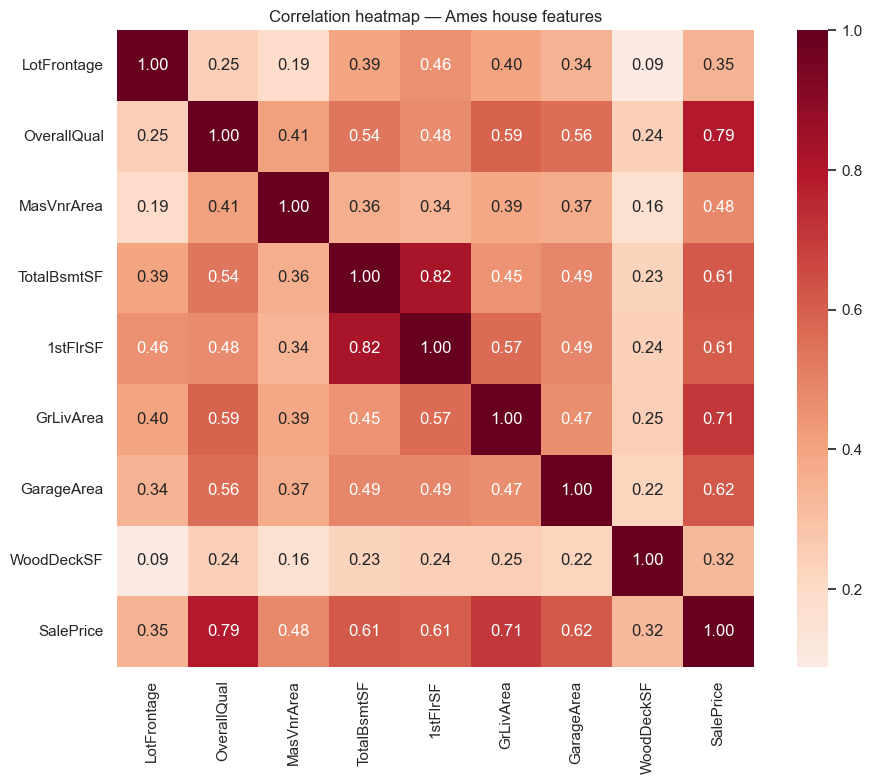

In [12]:
house_cols = [
    "OverallQual",
    "TotalBsmtSF",
    "1stFlrSF",
    "GrLivArea",
    "GarageArea",
    "WoodDeckSF",
    "LotFrontage",
    "MasVnrArea",
    "SalePrice",
]
house = pd.read_csv(HOUSE_CSV, usecols=house_cols)

corr = house.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation heatmap — Ames house features")
plt.tight_layout()
plt.show()

Here, OverallQual has the highest positive correlation (0.79) with SalesPrice column. Meaning we surely should consider OverallQual in X while SalesPrice in Y.


### 2. Boxplots (Titanic)

Reference diagram for the parts of a **box-and-whisker** plot (median, quartiles, whiskers, and outliers):

![Boxplot anatomy: whiskers, quartiles, median, and outlier points](boxplot_anatomy.png)

**What this graph is for:** A boxplot compresses a numeric distribution into a few robust statistics so you can **compare groups** side by side.

**How to read one box:**
- The **line inside the box** is the **median** (50th percentile).
- The **box** spans the **IQR** (interquartile range): from the 25th to the 75th percentile, i.e. the **middle half** of the data.
- **Whiskers** extend to a rule-based range (often about 1.5 times the IQR from the box); **points beyond** are plotted as individual dots (**outliers**).

**Left subplot (age by class and sex):** You see how **passenger age** differs between **1st / 2nd / 3rd class** and **female / male**. Wider boxes or higher medians mean older passengers in that group on average; many dots above/below the whiskers are unusually old or young fares.

**Right subplot (fare by survival):** Compare **ticket fare** for people who **died (0)** vs **survived (1)**. Higher median or a box shifted upward for survivors suggests survivors paid higher fares on average in this sample (exploratory only -- not proof of causation).


C:\Users\shahr\AppData\Local\Temp\ipykernel_35024\798324904.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Died", "Survived"])


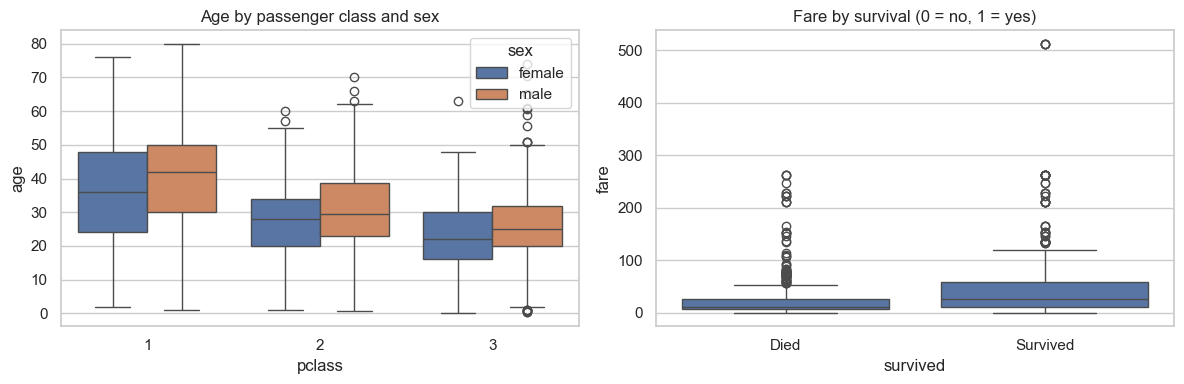

In [13]:
titanic = pd.read_csv(
    TITANIC_CSV, usecols=["pclass", "survived", "sex", "age", "fare"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=titanic, x="pclass", y="age", hue="sex", ax=axes[0])
axes[0].set_title("Age by passenger class and sex")

sns.boxplot(data=titanic, x="survived", y="fare", ax=axes[1])
axes[1].set_title("Fare by survival (0 = no, 1 = yes)")
axes[1].set_xticklabels(["Died", "Survived"])

plt.tight_layout()
plt.show()

Here, for the left graph 

For 1st class passengers ,

Most Female were between(the box shows) from ~25 to ~48
Most Male were between(the box shows) from ~32 to ~50 

For 2nd Class (pclass = 2),

Most Female were between  from ~22 to ~34
Most Male were between from ~25 to ~39 

For 3rd Class (pclass = 3),

Most Female were between from ~18 to ~30 
Most Male were between from ~20 to ~32 

### 3. Histogram, KDE, and normal reference

**What these graphs are for:** You want to see **shape** -- skewness, multiple peaks, heavy tails -- and optionally compare to a **bell curve**.


Here we have skewed, normal distribution graph and Q-Q plot

**Top-left Graph:** Histogram (bars) + KDE (smooth curve). House prices are usually **right-skewed**: a long tail toward expensive homes. That is why many models use **log(price)**.

**Top-right:** After a log transform, the shape is often **closer to symmetric**. The dashed red curve is a **theoretical normal distribution** with the **same mean and standard deviation** as the data -- a visual benchmark, not a claim that prices are exactly normal.

**Bottom-left:** Distribution of passenger ages (with KDE). You might see a bump for children and a wide adult spread; missing ages were dropped for this plot.

**Bottom-right :** Points are **quantiles of your data** vs **quantiles of a standard normal**. If the cloud **follows the diagonal**, the data are **close to normal** in the tails and center. **Systematic S-curves** mean heavier or lighter tails than a normal; **curved drift** means skew.

Run the cell above, then come back here and match what you see to these bullets.



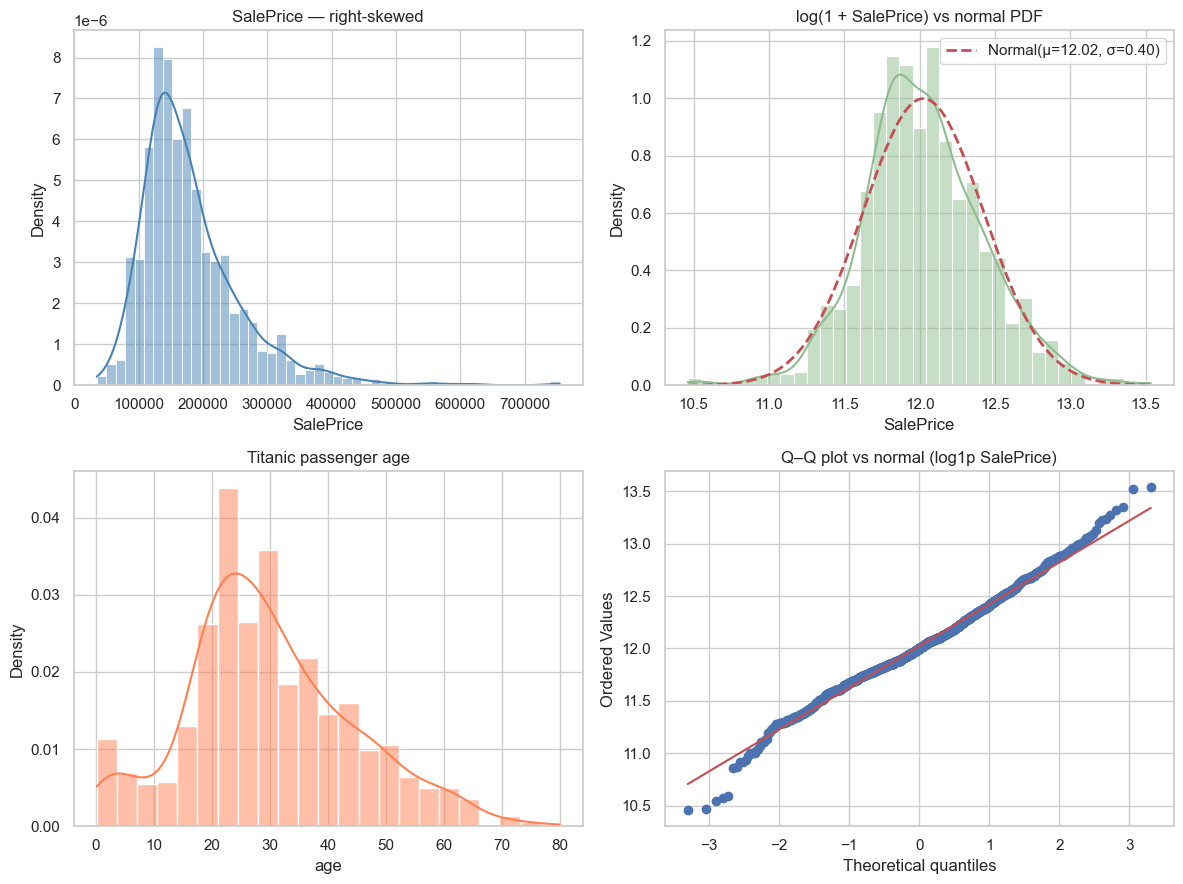

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sale = house["SalePrice"].dropna()
sns.histplot(sale, kde=True, stat="density", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("SalePrice — right-skewed")

log_sale = np.log1p(sale)
sns.histplot(log_sale, kde=True, stat="density", ax=axes[0, 1], color="darkseagreen")
mu, sigma = log_sale.mean(), log_sale.std()
xs = np.linspace(log_sale.min(), log_sale.max(), 200)
axes[0, 1].plot(
    xs,
    stats.norm.pdf(xs, mu, sigma),
    "r--",
    lw=2,
    label=f"Normal(μ={mu:.2f}, σ={sigma:.2f})",
)
axes[0, 1].legend()
axes[0, 1].set_title("log(1 + SalePrice) vs normal PDF")

age = titanic["age"].dropna()
sns.histplot(age, kde=True, stat="density", ax=axes[1, 0], color="coral")
axes[1, 0].set_title("Titanic passenger age")

stats.probplot(log_sale, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q–Q plot vs normal (log1p SalePrice)")

plt.tight_layout()
plt.show()

**What you should see in the four panels above:** Raw **SalePrice** is typically **skewed right**; **log1p** looks more symmetric. The **Q-Q** plot for log1p may be **roughly** straight in the middle with some deviation in the tails. **Age** may show a mix of children and adults rather than a single bell shape.


### 4. Violin plot (density + box)

**What this graph is for:** Like a boxplot, it compares a **numeric** variable across categories, but the **violin** width encodes **density**: where values are **more common**, the violin is **wider**.

**How to read it (split violins):** With split=True and **hue** (here sex), each x-category shows **two half-violins** (e.g. female vs male). You can compare **both** central tendency (box/whisker inside) and **full shape** (e.g. long tail of very high fares).

**What this figure shows:** **Fare** by **passenger class** and **sex**. First-class fares are typically higher and more spread out; third class is concentrated at lower fares. Use it together with the boxplots above -- boxplots emphasize quartiles; violins emphasize **modes** and **asymmetry**.



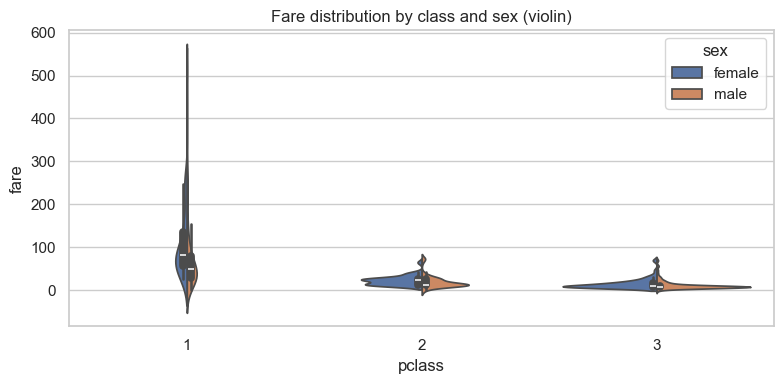

In [15]:
plt.figure(figsize=(8, 4))
sns.violinplot(data=titanic, x="pclass", y="fare", hue="sex", split=True)
plt.title("Fare distribution by class and sex (violin)")
plt.tight_layout()
plt.show()

The left most violin plot shows 1st class passenger fare violin plot, 
The violins are very tall and thin at the top. This means a few passengers paids very high fares around $550k. The widest part is near $80k meaning most 1st class passenger paid around 50k - 100k 

For 2nd class passenger's violin plot, 
Fares were within range 30k - 50k. There was a less difference between male and female's fare.

For 3rd class passenger's violin plot, 
Fares were between 10k - 30k. The difference between male and female fare was very low.
